# Graph Similarity Analysis Notebook

This notebook compares an embeddings graph matrix and a subscriptions graph matrix using a multi-metric workflow. Every stage is documented in separate cells so the full analysis can be audited end-to-end.

## 1) Scientific grounding

The statistical tests and matrix-comparison approach follow standard network-comparison practice (Mantel-style matrix correlation with permutation testing, QAP-style permutation logic, and dyadic matrix diagnostics such as correlation, error metrics, and overlap measures).

## 2) Load analysis libraries

This cell imports numerical, statistics, plotting, and file I/O dependencies used by later steps.

In [1]:
import json
import re
import shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr, spearmanr
from IPython.display import display


## 3) Define reusable functions

This cell defines matrix-loading helpers, alignment rules, permutation logic, metric calculations, and utility functions for diagnostics.

In [2]:
@dataclass
class SimilarityResult:
    """Container for all numeric outputs from the comparison pipeline."""

    comparison_mode: str
    analysis_space: str
    n_nodes: int
    n_pairs: int
    pearson_r: float
    pearson_p: float
    spearman_rho: float
    spearman_p: float
    cosine_similarity: float
    rmse: float
    mae: float
    edge_jaccard_by_threshold: Dict[str, float]
    mantel_r: float
    mantel_p: float
    qap_r: float
    qap_p: float


def resolve_latest_drive_csv(source: Path, download_dir: Path, label: Optional[str] = None) -> Path:
    """Copy the latest Google Drive CSV artifact to local runtime storage."""
    source = Path(str(source))
    source_str = str(source)

    if source.exists() and source.is_dir():
        candidate = source / 'adjacency_matrix.csv'
        if not candidate.exists():
            raise FileNotFoundError(f"Expected adjacency_matrix.csv under: {source}")
        source = candidate
        source_str = str(source)

    if any(ch in source_str for ch in "*?[]"):
        matches = sorted(Path('/').glob(source_str.lstrip('/')), key=lambda x: x.stat().st_mtime)
        if not matches:
            raise FileNotFoundError(f"No Google Drive CSV matched pattern: {source_str}")
        latest_source = matches[-1]
    else:
        if not source.exists():
            raise FileNotFoundError(f"Google Drive file not found: {source}")
        latest_source = source

    download_dir.mkdir(parents=True, exist_ok=True)
    safe_label = re.sub(r"[^A-Za-z0-9._-]+", "_", label or "artifact").strip("_") or "artifact"
    destination = download_dir / f"{safe_label}__{latest_source.name}"
    shutil.copy2(latest_source, destination)
    print(f"Downloaded latest Drive artifact: {latest_source} -> {destination}")
    return destination


def load_square_matrix(csv_path: Path) -> pd.DataFrame:
    """Load a labeled square matrix from CSV and enforce validity checks."""
    df = pd.read_csv(csv_path, index_col=0)

    if df.shape[0] != df.shape[1]:
        raise ValueError(f"Matrix at {csv_path} is not square: {df.shape}")

    df.index = df.index.map(str)
    df.columns = df.columns.map(str)

    if set(df.index) != set(df.columns):
        raise ValueError(f"Row/column label mismatch in {csv_path}")

    df = df.reindex(index=sorted(df.index), columns=sorted(df.columns))
    df = df.loc[df.index, df.index]
    df = df.apply(pd.to_numeric, errors='raise')
    return df


def align_matrices(a: pd.DataFrame, b: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    common = sorted(set(a.index).intersection(b.index))
    if len(common) < 3:
        raise ValueError('Need at least 3 shared nodes for robust similarity statistics.')
    return a.loc[common, common], b.loc[common, common]


def minmax_normalize(df: pd.DataFrame) -> pd.DataFrame:
    arr = df.to_numpy(dtype=float)
    v_min, v_max = np.nanmin(arr), np.nanmax(arr)
    if np.isclose(v_min, v_max):
        return pd.DataFrame(np.zeros_like(arr), index=df.index, columns=df.columns)
    return pd.DataFrame((arr - v_min) / (v_max - v_min), index=df.index, columns=df.columns)


def distances_to_similarity(df: pd.DataFrame) -> pd.DataFrame:
    return 1.0 - minmax_normalize(df)


def matrix_for_visualization(df: pd.DataFrame, visualization_space: str) -> pd.DataFrame:
    if visualization_space == 'distance':
        return df.copy()
    if visualization_space == 'similarity':
        return distances_to_similarity(df)
    raise ValueError("VISUALIZATION_SPACE must be 'distance' or 'similarity'.")


def row_sum_stats(df: pd.DataFrame) -> Dict[str, float]:
    row_sums = df.sum(axis=1).to_numpy(dtype=float)
    return {
        'row_sum_min': float(np.min(row_sums)),
        'row_sum_max': float(np.max(row_sums)),
        'row_sum_mean': float(np.mean(row_sums)),
        'row_sum_max_abs_deviation_from_1': float(np.max(np.abs(row_sums - 1.0))),
    }


def is_symmetric(df: pd.DataFrame, atol: float = 1e-10) -> bool:
    arr = df.to_numpy(dtype=float)
    return bool(np.allclose(arr, arr.T, atol=atol, rtol=0.0))


def max_asymmetry(df: pd.DataFrame) -> float:
    arr = df.to_numpy(dtype=float)
    return float(np.max(np.abs(arr - arr.T)))


def off_diagonal_vector(df: pd.DataFrame) -> np.ndarray:
    arr = df.to_numpy(dtype=float)
    mask = ~np.eye(arr.shape[0], dtype=bool)
    return arr[mask]


def jaccard_threshold_sweep(a_vec: np.ndarray, b_vec: np.ndarray, thresholds: np.ndarray) -> Dict[str, float]:
    out: Dict[str, float] = {}
    for t in thresholds:
        a_edge = a_vec >= t
        b_edge = b_vec >= t
        inter = np.logical_and(a_edge, b_edge).sum()
        union = np.logical_or(a_edge, b_edge).sum()
        out[f"{float(t):.2f}"] = float(inter / union) if union > 0 else float('nan')
    return out


def permutation_distribution(a: pd.DataFrame, b: pd.DataFrame, permutations: int = 2000, random_state: int = 42) -> Tuple[float, np.ndarray]:
    rng = np.random.default_rng(random_state)
    a_vec = off_diagonal_vector(a)
    b_vec = off_diagonal_vector(b)
    obs_r, _ = pearsonr(a_vec, b_vec)

    n = a.shape[0]
    b_arr = b.to_numpy(dtype=float)
    perm_stats = np.empty(permutations, dtype=float)

    for i in range(permutations):
        p = rng.permutation(n)
        b_perm = pd.DataFrame(b_arr[np.ix_(p, p)], index=a.index, columns=a.columns)
        perm_stats[i], _ = pearsonr(a_vec, off_diagonal_vector(b_perm))

    return float(obs_r), perm_stats


def mantel_test(a: pd.DataFrame, b: pd.DataFrame, permutations: int = 2000, random_state: int = 42) -> Tuple[float, float]:
    obs_r, perm_stats = permutation_distribution(a, b, permutations=permutations, random_state=random_state)
    p_value = (np.sum(np.abs(perm_stats) >= np.abs(obs_r)) + 1) / (permutations + 1)
    return float(obs_r), float(p_value)


def qap_correlation(a: pd.DataFrame, b: pd.DataFrame, permutations: int = 2000, random_state: int = 7) -> Tuple[float, float]:
    obs_r, perm_stats = permutation_distribution(a, b, permutations=permutations, random_state=random_state)
    p_value = (np.sum(perm_stats >= obs_r) + 1) / (permutations + 1)
    return float(obs_r), float(p_value)


def compute_similarity_metrics(embeddings_matrix: pd.DataFrame, subscriptions_matrix: pd.DataFrame, comparison_mode: str, analysis_space: str, edge_thresholds: np.ndarray, permutations: int) -> SimilarityResult:
    emb_vec = off_diagonal_vector(embeddings_matrix)
    sub_vec = off_diagonal_vector(subscriptions_matrix)

    pear_r, pear_p = pearsonr(emb_vec, sub_vec)
    spr_rho, spr_p = spearmanr(emb_vec, sub_vec)
    cos_sim = 1.0 - cosine(emb_vec, sub_vec)
    rmse = float(np.sqrt(np.mean((emb_vec - sub_vec) ** 2)))
    mae = float(np.mean(np.abs(emb_vec - sub_vec)))
    edge_jaccard_by_threshold = jaccard_threshold_sweep(emb_vec, sub_vec, edge_thresholds)
    mantel_r, mantel_p = mantel_test(embeddings_matrix, subscriptions_matrix, permutations)
    qap_r, qap_p = qap_correlation(embeddings_matrix, subscriptions_matrix, permutations)

    return SimilarityResult(
        comparison_mode=comparison_mode,
        analysis_space=analysis_space,
        n_nodes=embeddings_matrix.shape[0],
        n_pairs=emb_vec.size,
        pearson_r=float(pear_r),
        pearson_p=float(pear_p),
        spearman_rho=float(spr_rho),
        spearman_p=float(spr_p),
        cosine_similarity=float(cos_sim),
        rmse=rmse,
        mae=mae,
        edge_jaccard_by_threshold=edge_jaccard_by_threshold,
        mantel_r=mantel_r,
        mantel_p=mantel_p,
        qap_r=qap_r,
        qap_p=qap_p,
    )


## 4) Configure runtime inputs

Set Google Drive input paths, output directory, and analysis parameters. The default mode compares native directed row-normalized distances.

In [3]:
EMBEDDINGS_DRIVE_SOURCE = Path('/content/drive/MyDrive/Graphiko/graphs/embeddings_distance/latest/adjacency_matrix.csv')
SUBSCRIPTIONS_DRIVE_SOURCE = Path('/content/drive/MyDrive/Graphiko/graphs/subscriptions_normalized_distance/latest/adjacency_matrix.csv')
LOCAL_DOWNLOAD_DIR = Path('inputs/downloaded_from_drive')
OUTPUT_DIR = Path('outputs/graph_similarity')

COMPARISON_MODE = 'directed_row_normalized_distance'
ANALYSIS_SPACE = 'native_distance'
VISUALIZATION_SPACE = 'distance'  # 'distance' or 'similarity'

EDGE_THRESHOLDS = np.array([0.10, 0.20, 0.30, 0.40, 0.50])
PERMUTATIONS = 2000


## 5) Mount Google Drive

This cell mounts Drive so the notebook can fetch the most recent matrix artifacts.

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 6) Load, validate, and align matrices

This cell downloads the latest files, validates matrix shape/labels, and aligns both matrices to their shared node set so metrics compare the same ordered pairs.

In [5]:
EMBEDDINGS_CSV = resolve_latest_drive_csv(EMBEDDINGS_DRIVE_SOURCE, LOCAL_DOWNLOAD_DIR, label='embeddings')
SUBSCRIPTIONS_CSV = resolve_latest_drive_csv(SUBSCRIPTIONS_DRIVE_SOURCE, LOCAL_DOWNLOAD_DIR, label='subscriptions')

emb_raw = load_square_matrix(EMBEDDINGS_CSV)
sub_raw = load_square_matrix(SUBSCRIPTIONS_CSV)
emb_aligned, sub_aligned = align_matrices(emb_raw, sub_raw)

if ANALYSIS_SPACE != 'native_distance':
    raise ValueError("ANALYSIS_SPACE must remain 'native_distance' for this notebook default path.")

emb_analysis = emb_aligned.copy()
sub_analysis = sub_aligned.copy()
emb_plot = matrix_for_visualization(emb_analysis, VISUALIZATION_SPACE)
sub_plot = matrix_for_visualization(sub_analysis, VISUALIZATION_SPACE)

print(f'Aligned node count: {emb_analysis.shape[0]}')
print(f'Ordered pair count (off-diagonal): {off_diagonal_vector(emb_analysis).size}')


Downloaded latest Drive artifact: /content/drive/MyDrive/Graphiko/graphs/embeddings_distance/latest/adjacency_matrix.csv -> inputs/downloaded_from_drive/embeddings__adjacency_matrix.csv
Downloaded latest Drive artifact: /content/drive/MyDrive/Graphiko/graphs/subscriptions_normalized_distance/latest/adjacency_matrix.csv -> inputs/downloaded_from_drive/subscriptions__adjacency_matrix.csv
Aligned node count: 27
Ordered pair count (off-diagonal): 702


## 7) Compute similarity metrics

This cell runs all metrics in native distance space and stores outputs for reporting and interpretation.

In [6]:
result = compute_similarity_metrics(
    emb_analysis,
    sub_analysis,
    comparison_mode=COMPARISON_MODE,
    analysis_space=ANALYSIS_SPACE,
    edge_thresholds=EDGE_THRESHOLDS,
    permutations=PERMUTATIONS,
)

metrics = asdict(result)
metrics_df = pd.DataFrame([
    {
        'metric': 'pearson_r', 'value': metrics['pearson_r']
    },
    {
        'metric': 'pearson_p', 'value': metrics['pearson_p']
    },
    {
        'metric': 'spearman_rho', 'value': metrics['spearman_rho']
    },
    {
        'metric': 'spearman_p', 'value': metrics['spearman_p']
    },
    {
        'metric': 'cosine_similarity', 'value': metrics['cosine_similarity']
    },
    {
        'metric': 'rmse', 'value': metrics['rmse']
    },
    {
        'metric': 'mae', 'value': metrics['mae']
    },
    {
        'metric': 'mantel_r', 'value': metrics['mantel_r']
    },
    {
        'metric': 'mantel_p', 'value': metrics['mantel_p']
    },
    {
        'metric': 'qap_r', 'value': metrics['qap_r']
    },
    {
        'metric': 'qap_p', 'value': metrics['qap_p']
    },
])
display(metrics_df)
print('Edge Jaccard by threshold:', metrics['edge_jaccard_by_threshold'])


,metric,value
0,pearson_r,0.119109
1,pearson_p,0.001570
2,spearman_rho,0.156166
3,spearman_p,0.000032
4,cosine_similarity,0.894906
5,rmse,0.019214
6,mae,0.012619
7,mantel_r,0.119109
8,mantel_p,0.184908
9,qap_r,0.119109


Edge Jaccard by threshold: {'0.10': 0.0, '0.20': nan, '0.30': nan, '0.40': nan, '0.50': nan}


## 8) Interpret each metric

This cell explains what every reported metric means and how to interpret high/low values when comparing graph matrices.

In [7]:
interpretation = pd.DataFrame([
    {'metric': 'Pearson r', 'what_it_measures': 'Linear association between directed off-diagonal edge distances in both matrices.', 'how_to_interpret': 'Closer to +1 means strong linear agreement; near 0 means weak linear relationship; negative means inverse relationship.'},
    {'metric': 'Pearson p-value', 'what_it_measures': 'Significance test for Pearson linear association.', 'how_to_interpret': 'Smaller values indicate stronger evidence that linear association is not due to random chance.'},
    {'metric': 'Spearman rho', 'what_it_measures': 'Rank-order agreement of directed edge distances.', 'how_to_interpret': 'Closer to +1 means both matrices preserve similar ordering of pairwise distances, even if scales differ.'},
    {'metric': 'Spearman p-value', 'what_it_measures': 'Significance test for rank-order association.', 'how_to_interpret': 'Smaller values indicate stronger evidence of non-random rank alignment.'},
    {'metric': 'Cosine similarity', 'what_it_measures': 'Angular similarity between the two off-diagonal edge-weight vectors.', 'how_to_interpret': 'Closer to 1 means similar directional pattern of edge weights; closer to 0 means weak directional agreement.'},
    {'metric': 'RMSE', 'what_it_measures': 'Root mean squared error between directed edge distances.', 'how_to_interpret': 'Lower is better; larger values indicate larger typical edge-level deviations with extra penalty for large errors.'},
    {'metric': 'MAE', 'what_it_measures': 'Mean absolute error between directed edge distances.', 'how_to_interpret': 'Lower is better; gives average absolute mismatch in edge distances.'},
    {'metric': 'Edge Jaccard (threshold sweep)', 'what_it_measures': 'Overlap of directed edges that pass each threshold in both matrices.', 'how_to_interpret': 'Closer to 1 means stronger overlap of selected edges at that threshold; closer to 0 means little overlap.'},
    {'metric': 'Mantel r', 'what_it_measures': 'Matrix correlation using permutation-based null distribution.', 'how_to_interpret': 'Higher positive values indicate stronger matrix-level structural alignment.'},
    {'metric': 'Mantel p-value', 'what_it_measures': 'Two-sided permutation significance for Mantel r.', 'how_to_interpret': 'Smaller values indicate observed matrix correlation is unlikely under random node relabeling.'},
    {'metric': 'QAP r', 'what_it_measures': 'QAP-style matrix correlation under node-label permutations.', 'how_to_interpret': 'Higher values indicate stronger association of directed ties across the two matrices.'},
    {'metric': 'QAP p-value', 'what_it_measures': 'One-sided permutation significance for QAP correlation.', 'how_to_interpret': 'Smaller values indicate stronger evidence that observed positive association is not random.'},
])
display(interpretation)


,metric,what_it_measures,how_to_interpret
0,Pearson r,Linear association between directed off-diagon...,Closer to +1 means strong linear agreement; ne...
1,Pearson p-value,Significance test for Pearson linear association.,Smaller values indicate stronger evidence that...
2,Spearman rho,Rank-order agreement of directed edge distances.,Closer to +1 means both matrices preserve simi...
3,Spearman p-value,Significance test for rank-order association.,Smaller values indicate stronger evidence of n...
4,Cosine similarity,Angular similarity between the two off-diagona...,Closer to 1 means similar directional pattern ...
5,RMSE,Root mean squared error between directed edge ...,Lower is better; larger values indicate larger...
6,MAE,Mean absolute error between directed edge dist...,Lower is better; gives average absolute mismat...
7,Edge Jaccard (threshold sweep),Overlap of directed edges that pass each thres...,Closer to 1 means stronger overlap of selected...
8,Mantel r,Matrix correlation using permutation-based nul...,Higher positive values indicate stronger matri...
9,Mantel p-value,Two-sided permutation significance for Mantel r.,Smaller values indicate observed matrix correl...


## 9) Persist outputs to disk

This cell saves numeric outputs and run metadata so results can be reused outside the notebook.

In [8]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
metrics_json = OUTPUT_DIR / 'similarity_metrics.json'
metrics_csv = OUTPUT_DIR / 'similarity_metrics.csv'
summary_json = OUTPUT_DIR / 'run_summary.json'

with metrics_json.open('w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame([metrics]).to_csv(metrics_csv, index=False)

summary = {
    'inputs': {
        'embeddings_drive_source': str(EMBEDDINGS_DRIVE_SOURCE),
        'subscriptions_drive_source': str(SUBSCRIPTIONS_DRIVE_SOURCE),
        'embeddings_downloaded_csv': str(EMBEDDINGS_CSV),
        'subscriptions_downloaded_csv': str(SUBSCRIPTIONS_CSV),
        'comparison_mode': COMPARISON_MODE,
        'analysis_space': ANALYSIS_SPACE,
        'visualization_space': VISUALIZATION_SPACE,
        'edge_thresholds': [float(x) for x in EDGE_THRESHOLDS],
    },
    'matrix_diagnostics': {
        'embeddings': {
            'is_symmetric': is_symmetric(emb_analysis),
            'max_asymmetry': max_asymmetry(emb_analysis),
            **row_sum_stats(emb_analysis),
        },
        'subscriptions': {
            'is_symmetric': is_symmetric(sub_analysis),
            'max_asymmetry': max_asymmetry(sub_analysis),
            **row_sum_stats(sub_analysis),
        },
    },
    'metrics_json': str(metrics_json),
    'metrics_csv': str(metrics_csv),
}

with summary_json.open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('Saved metrics and run summary.')


Saved metrics and run summary.


## 10) Graph 1 — Side-by-side heatmaps

This visualization compares the full matrix structure in the selected visualization space. Look for shared blocks, gradients, and concentration zones to evaluate global structural similarity.

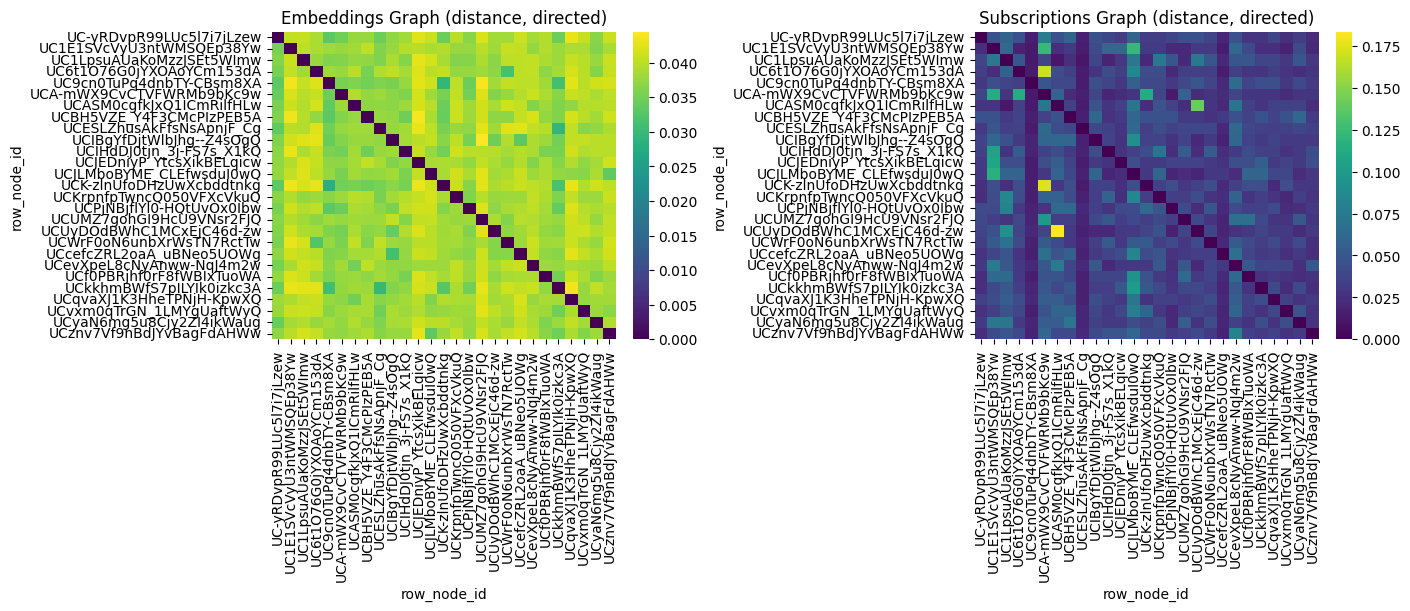

Saved: outputs/graph_similarity/heatmaps_side_by_side.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
sns.heatmap(emb_plot, cmap='viridis', ax=axes[0], cbar=True)
axes[0].set_title(f'Embeddings Graph ({VISUALIZATION_SPACE}, directed)')
sns.heatmap(sub_plot, cmap='viridis', ax=axes[1], cbar=True)
axes[1].set_title(f'Subscriptions Graph ({VISUALIZATION_SPACE}, directed)')

heatmaps_path = OUTPUT_DIR / 'heatmaps_side_by_side.png'
fig.savefig(heatmaps_path, dpi=220)
plt.show()
print(f'Saved: {heatmaps_path}')


## 11) Graph 2 — Difference heatmap

This plot shows (Embeddings − Subscriptions) per directed pair. Positive regions indicate where embeddings distances are larger; negative regions indicate where subscriptions distances are larger.

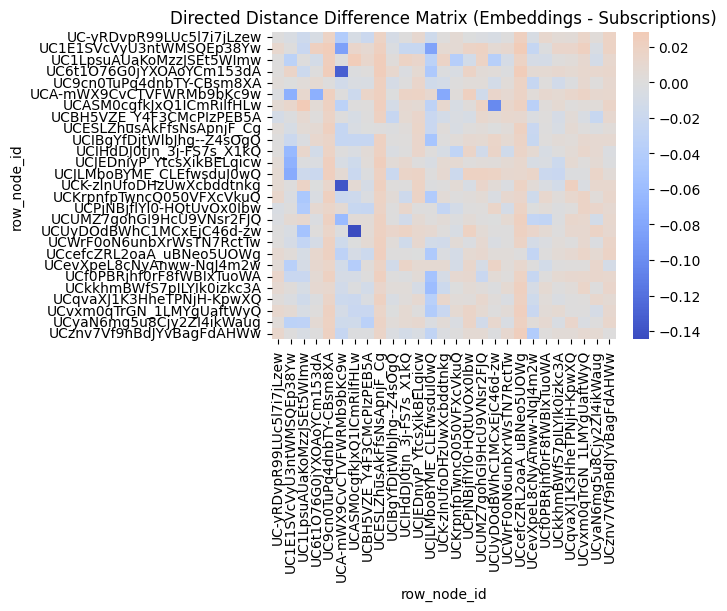

Saved: outputs/graph_similarity/difference_heatmap.png


In [10]:
diff = emb_analysis - sub_analysis
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sns.heatmap(diff, cmap='coolwarm', center=0.0, ax=ax)
ax.set_title('Directed Distance Difference Matrix (Embeddings - Subscriptions)')

diff_path = OUTPUT_DIR / 'difference_heatmap.png'
fig.savefig(diff_path, dpi=220)
plt.show()
print(f'Saved: {diff_path}')


## 12) Graph 3 — Directed edge-weight scatter

This scatter plot compares each ordered-pair distance in embeddings vs subscriptions. Points near a diagonal trend indicate pairwise agreement; spread indicates local mismatches.

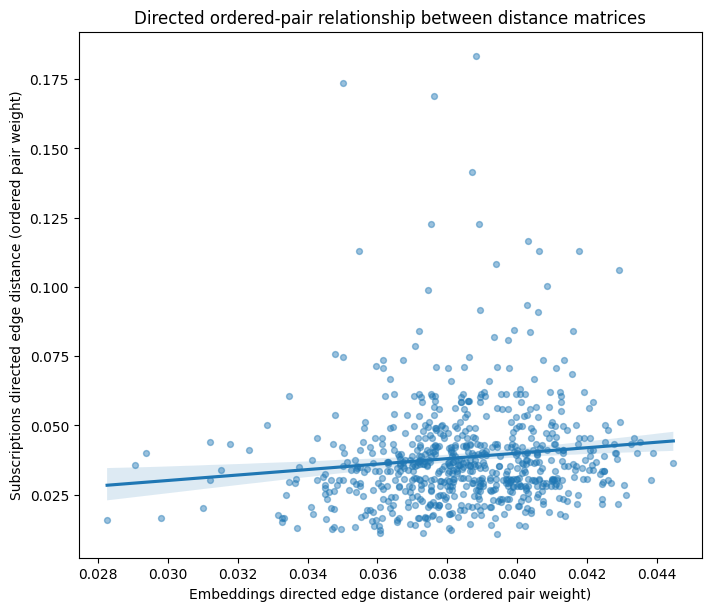

Saved: outputs/graph_similarity/edge_weight_scatter.png


In [11]:
emb_vec = off_diagonal_vector(emb_analysis)
sub_vec = off_diagonal_vector(sub_analysis)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sns.regplot(x=emb_vec, y=sub_vec, scatter_kws={'alpha': 0.45, 's': 18}, ax=ax)
ax.set_xlabel('Embeddings directed edge distance (ordered pair weight)')
ax.set_ylabel('Subscriptions directed edge distance (ordered pair weight)')
ax.set_title('Directed ordered-pair relationship between distance matrices')

scatter_path = OUTPUT_DIR / 'edge_weight_scatter.png'
fig.savefig(scatter_path, dpi=220)
plt.show()
print(f'Saved: {scatter_path}')


## 13) Graph 4 — Edge-distance distributions

This overlay compares the overall distributions of directed edge distances. Strong overlap implies similar global distance profiles; divergence implies different weight regimes.

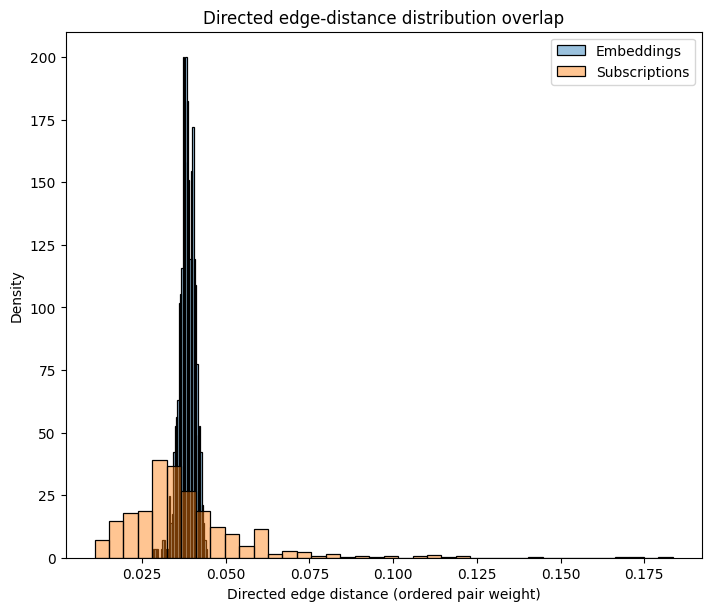

Saved: outputs/graph_similarity/edge_weight_distributions.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sns.histplot(emb_vec, bins=40, color='#1f77b4', alpha=0.45, stat='density', label='Embeddings', ax=ax)
sns.histplot(sub_vec, bins=40, color='#ff7f0e', alpha=0.45, stat='density', label='Subscriptions', ax=ax)
ax.set_xlabel('Directed edge distance (ordered pair weight)')
ax.set_ylabel('Density')
ax.set_title('Directed edge-distance distribution overlap')
ax.legend()

dist_path = OUTPUT_DIR / 'edge_weight_distributions.png'
fig.savefig(dist_path, dpi=220)
plt.show()
print(f'Saved: {dist_path}')


## 14) Graph 5 — Permutation null distributions

These histograms show null distributions under random node relabeling for Mantel-style and QAP-style correlations. The vertical line is the observed statistic; farther into the tail indicates stronger evidence of non-random alignment.

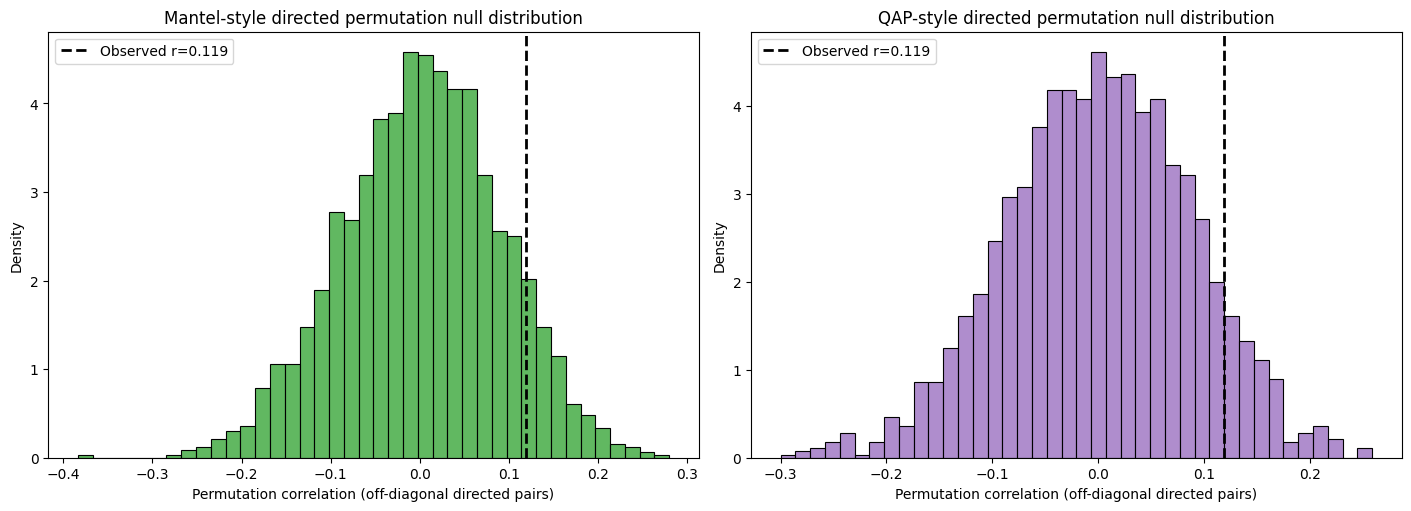

Saved: outputs/graph_similarity/permutation_null_distributions.png


In [13]:
mantel_obs, mantel_perm = permutation_distribution(emb_analysis, sub_analysis, permutations=PERMUTATIONS, random_state=42)
qap_obs, qap_perm = permutation_distribution(emb_analysis, sub_analysis, permutations=PERMUTATIONS, random_state=7)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.histplot(mantel_perm, bins=40, stat='density', color='#2ca02c', alpha=0.75, ax=axes[0])
axes[0].axvline(mantel_obs, color='black', linestyle='--', linewidth=2, label=f'Observed r={mantel_obs:.3f}')
axes[0].set_title('Mantel-style directed permutation null distribution')
axes[0].set_xlabel('Permutation correlation (off-diagonal directed pairs)')
axes[0].legend()

sns.histplot(qap_perm, bins=40, stat='density', color='#9467bd', alpha=0.75, ax=axes[1])
axes[1].axvline(qap_obs, color='black', linestyle='--', linewidth=2, label=f'Observed r={qap_obs:.3f}')
axes[1].set_title('QAP-style directed permutation null distribution')
axes[1].set_xlabel('Permutation correlation (off-diagonal directed pairs)')
axes[1].legend()

nulls_path = OUTPUT_DIR / 'permutation_null_distributions.png'
fig.savefig(nulls_path, dpi=220)
plt.show()
print(f'Saved: {nulls_path}')


## 15) Final run summary

This final cell prints file locations and key diagnostics so the notebook run is reproducible and easy to review.

In [14]:
summary['plots'] = {
    'heatmaps': str(heatmaps_path),
    'difference_heatmap': str(diff_path),
    'scatter': str(scatter_path),
    'distribution_overlap': str(dist_path),
    'permutation_nulls': str(nulls_path),
}

with summary_json.open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('Graph similarity analysis complete.')
print(json.dumps(summary, indent=2))


Graph similarity analysis complete.
{
  "inputs": {
    "embeddings_drive_source": "/content/drive/MyDrive/Graphiko/graphs/embeddings_distance/latest/adjacency_matrix.csv",
    "subscriptions_drive_source": "/content/drive/MyDrive/Graphiko/graphs/subscriptions_normalized_distance/latest/adjacency_matrix.csv",
    "embeddings_downloaded_csv": "inputs/downloaded_from_drive/embeddings__adjacency_matrix.csv",
    "subscriptions_downloaded_csv": "inputs/downloaded_from_drive/subscriptions__adjacency_matrix.csv",
    "comparison_mode": "directed_row_normalized_distance",
    "analysis_space": "native_distance",
    "visualization_space": "distance",
    "edge_thresholds": [
      0.1,
      0.2,
      0.3,
      0.4,
      0.5
    ]
  },
  "matrix_diagnostics": {
    "embeddings": {
      "is_symmetric": false,
      "max_asymmetry": 0.005819547518985099,
      "row_sum_min": 0.9999999999999984,
      "row_sum_max": 0.9999999999999993,
      "row_sum_mean": 0.999999999999999,
      "row_sum_